In [14]:
import pandas as pd
import numpy as numpy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('../../data/processed/bank_data_preprocessed_v2.csv')


In [3]:
nominal_cols = ['job', 'marital']
df_processed = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

categorical_cols = ['default', 'housing', 'loan']
for col in categorical_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed.drop(columns=['month'], inplace=True)

In [4]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)
y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [5]:
# Scale only continuous numerical columns (not binary/OHE flags)
scale_cols = ['age', 'balance_log1p', 'pdays_contacted', 'pdays_contacted', 'campaign_capped', 'previous_log1p']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print("Columns standardized (mean≈0, std≈1):")
print(X_scaled[scale_cols].describe().round(3).loc[['mean','std']])

Columns standardized (mean≈0, std≈1):
      age  balance_log1p  pdays_contacted  pdays_contacted  campaign_capped  \
mean  0.0           -0.0              0.0              0.0              0.0   
std   1.0            1.0              1.0              1.0              1.0   

      previous_log1p  
mean            -0.0  
std              1.0  


In [6]:
X_scaled['pdays_contacted'] = X_scaled['pdays_contacted'].fillna(999)

In [7]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,       # 80% train | 20% test
    random_state=42,
    stratify=y            # preserve class balance
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 51)  |  y: (8929,)
  Test   → X: (2233, 51)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4231 (47.4%)  no=4698 (52.6%)
  Test   yes=1058 (47.4%)  no=1175 (52.6%)


In [8]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay

nb = BernoulliNB()
nb.fit(X_train, y_train)

BernoulliNB()

In [9]:
y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)[:, 1]

In [12]:

y_pred_nb  = nb.predict(X_test)
y_prob_nb  = nb.predict_proba(X_test)[:, 1]

acc_nb     = accuracy_score(y_test, y_pred_nb)
auc_nb     = roc_auc_score(y_test, y_prob_nb)
cv_scores_nb = cross_val_score(nb, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Bernoulli Naive Bayes — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_nb:.4f}  ({acc_nb*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_nb:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_nb.mean():.4f}  ± {cv_scores_nb.std():.4f}")

   Bernoulli Naive Bayes — Optimised Performance
  Test Accuracy     : 0.6740  (67.40%)
  ROC-AUC Score     : 0.7305
  5-Fold CV Mean    : 0.6595  ± 0.1243


In [13]:
bool_cols = X_train.select_dtypes(include=["bool"]).columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

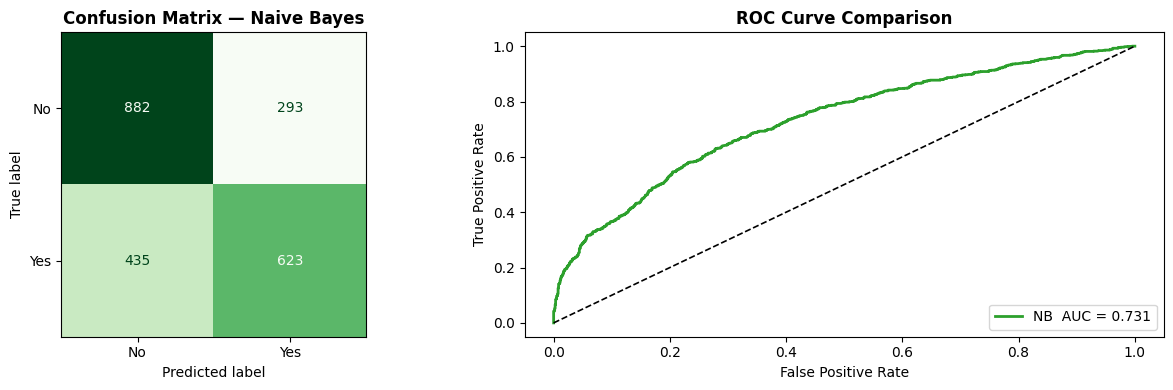

In [15]:
# ── 8.5  Confusion Matrix & ROC Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(cm_nb, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Naive Bayes', fontweight='bold')

# ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
axes[1].plot(fpr_nb, tpr_nb, color='#2ca02c', lw=2, label=f'NB  AUC = {auc_nb:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1.2)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Feature importance

In [17]:
# ── 7.6  Feature Importance — Naive Bayes ──────────────────────────────────
import numpy as np
import pandas as pd

feature_names = X_train.columns

importance_nb = np.abs(nb.feature_log_prob_[1] - nb.feature_log_prob_[0])

importances_nb = pd.Series(importance_nb, index=feature_names)\
    .sort_values(ascending=False)

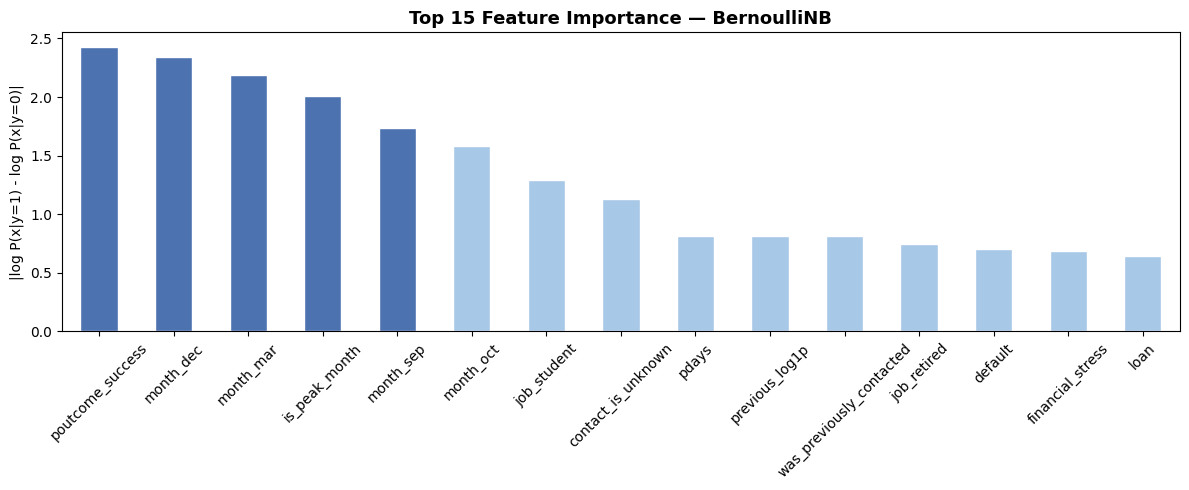

poutcome_success      2.430344
month_dec             2.338244
month_mar             2.184093
is_peak_month         2.011582
month_sep             1.733892
month_oct             1.578651
job_student           1.289878
contact_is_unknown    1.127689
pdays                 0.811592
previous_log1p        0.811592
dtype: float64


In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

top_n = 15
colors = ['#4C72B0' if i < 5 else '#A8C8E8' for i in range(top_n)]

importances_nb.head(top_n).plot(
    kind='bar',
    color=colors,
    edgecolor='white',
    ax=ax
)

ax.set_title(f'Top {top_n} Feature Importance — BernoulliNB',
             fontsize=13, fontweight='bold')
ax.set_ylabel('|log P(x|y=1) - log P(x|y=0)|')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(importances_nb.head(10))

### log-odds

<Axes: >

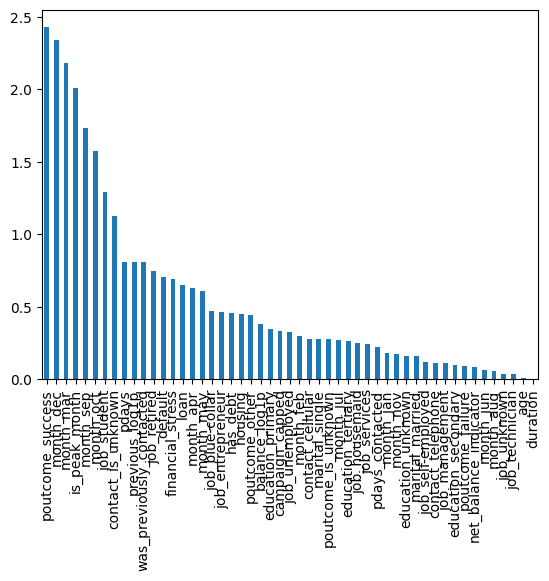

In [25]:
importance = np.abs(nb.feature_log_prob_[1] - nb.feature_log_prob_[0])

pd.Series(importance, index=X_train.columns)\
    .sort_values(ascending=False)\
    .plot.bar()

In [38]:
importance = np.abs(
    nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
)

pd.Series(importance, index=X.columns)\
    .sort_values(ascending=False)

poutcome_success            2.430344
month_dec                   2.338244
month_mar                   2.184093
is_peak_month               2.011582
month_sep                   1.733892
month_oct                   1.578651
job_student                 1.289878
contact_is_unknown          1.127689
pdays                       0.811592
previous_log1p              0.811592
was_previously_contacted    0.811592
job_retired                 0.744517
default                     0.703565
financial_stress            0.688047
loan                        0.647375
month_apr                   0.631069
month_may                   0.608272
job_blue-collar             0.467453
job_entrepreneur            0.462615
has_debt                    0.456378
housing                     0.447358
poutcome_other              0.445084
balance_log1p               0.377735
education_primary           0.346751
campaign_capped             0.329590
job_unemployed              0.326194
month_feb                   0.301362
c

In [39]:
from sklearn.inspection import permutation_importance

r = permutation_importance(nb, X_test, y_test, n_repeats=10)

pd.Series(r.importances_mean, index=X.columns)\
    .sort_values(ascending=False)

has_debt                    0.007389
poutcome_success            0.005240
housing                     0.005060
job_retired                 0.004926
pdays_contacted             0.003941
contact_is_unknown          0.003359
is_peak_month               0.003314
balance_log1p               0.003090
month_oct                   0.002821
net_balance_indicator       0.002418
month_mar                   0.002329
job_student                 0.002015
month_may                   0.001702
month_apr                   0.001299
education_primary           0.001120
month_aug                   0.000896
month_jan                   0.000851
month_nov                   0.000717
month_dec                   0.000582
job_technician              0.000448
month_sep                   0.000403
month_jul                   0.000313
poutcome_failure            0.000179
was_previously_contacted    0.000179
pdays                       0.000179
poutcome_is_unknown         0.000179
previous_log1p              0.000179
a

## Feature counterfactual

In [40]:
from sklearn.naive_bayes import BernoulliNB

### a) Sprawdzenie `contact_cellular`

In [41]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB

# ── TREATMENT ─────────────────────────────
T = df_processed['contact_cellular'].astype(int).values
Y = df_processed['deposit'].astype(int).values

confounders = [

    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',

    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',

    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',

    'marital_married',
    'marital_single',

    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',

    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',

    'campaign_capped'
]

confounders = [c for c in confounders if c in df_processed.columns]

W = df_processed[confounders].astype(float).fillna(0).values

In [42]:
# split data
X_treated = W[T == 1]
Y_treated = Y[T == 1]

X_control = W[T == 0]
Y_control = Y[T == 0]

# NB models
nb_treated = BernoulliNB().fit(X_treated, Y_treated)
nb_control = BernoulliNB().fit(X_control, Y_control)

In [43]:
# P(Y=1 | T=1)
p_treated = nb_treated.predict_proba(W)[:, 1]

# P(Y=1 | T=0)
p_control = nb_control.predict_proba(W)[:, 1]

# individual treatment effect
ite = p_treated - p_control

In [44]:
ate = ite.mean()

ci_lower = np.percentile(ite, 2.5)
ci_upper = np.percentile(ite, 97.5)

print("=== Naive Bayes Counterfactual (contact_cellular) ===")
print(f"ATE: {ate:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

print("\nHeterogeniczność:")
print(f"std: {ite.std():.4f}")
print(f"min: {ite.min():.4f}, max: {ite.max():.4f}")
print(f"% positive effect: {(ite > 0).mean():.1%}")

=== Naive Bayes Counterfactual (contact_cellular) ===
ATE: 0.0074
95% CI: [-0.4850, 0.1989]

Heterogeniczność:
std: 0.1605
min: -0.8386, max: 0.2866
% positive effect: 54.4%


### b) Sprawdzenie `campaign_capped `

In [52]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB

# ── TREATMENT ─────────────────────────────
T = (df_processed['campaign_capped'] > 1).astype(int)
Y = df_processed['deposit'].astype(int).values

confounders = [

    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',

    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',

    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',

    'marital_married',
    'marital_single',

    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',

    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',

    'contact_cellular',
]

confounders = [c for c in confounders if c in df_processed.columns]

W = df_processed[confounders].astype(float).fillna(0).values

In [53]:
# split data
X_treated = W[T == 1]
Y_treated = Y[T == 1]

X_control = W[T == 0]
Y_control = Y[T == 0]

# NB models
nb_treated = BernoulliNB().fit(X_treated, Y_treated)
nb_control = BernoulliNB().fit(X_control, Y_control)

In [54]:
# P(Y=1 | T=1)
p_treated = nb_treated.predict_proba(W)[:, 1]

# P(Y=1 | T=0)
p_control = nb_control.predict_proba(W)[:, 1]

# individual treatment effect
ite = p_treated - p_control

In [55]:
ate = ite.mean()

ci_lower = np.percentile(ite, 2.5)
ci_upper = np.percentile(ite, 97.5)

print("=== Naive Bayes Counterfactual (contact_cellular) ===")
print(f"ATE: {ate:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

print("\nHeterogeniczność:")
print(f"std: {ite.std():.4f}")
print(f"min: {ite.min():.4f}, max: {ite.max():.4f}")
print(f"% positive effect: {(ite > 0).mean():.1%}")

=== Naive Bayes Counterfactual (contact_cellular) ===
ATE: -0.0303
95% CI: [-0.2203, 0.1148]

Heterogeniczność:
std: 0.0856
min: -0.3019, max: 0.3126
% positive effect: 47.3%


### c) Sprawdzenie `was_previously_contacted`

In [56]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import BernoulliNB

# ── TREATMENT ─────────────────────────────
T = df_processed['was_previously_contacted'].astype(int).values
Y = df_processed['deposit'].astype(int).values

confounders = [

    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',

    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',

    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',

    'marital_married',
    'marital_single',

    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',

    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',

    'contact_cellular',
    'campaign_capped'
]

confounders = [c for c in confounders if c in df_processed.columns]

W = df_processed[confounders].astype(float).fillna(0).values

In [57]:
# split data
X_treated = W[T == 1]
Y_treated = Y[T == 1]

X_control = W[T == 0]
Y_control = Y[T == 0]

# NB models
nb_treated = BernoulliNB().fit(X_treated, Y_treated)
nb_control = BernoulliNB().fit(X_control, Y_control)

In [58]:
# P(Y=1 | T=1)
p_treated = nb_treated.predict_proba(W)[:, 1]

# P(Y=1 | T=0)
p_control = nb_control.predict_proba(W)[:, 1]

# individual treatment effect
ite = p_treated - p_control

In [59]:
ate = ite.mean()

ci_lower = np.percentile(ite, 2.5)
ci_upper = np.percentile(ite, 97.5)

print("=== Naive Bayes Counterfactual (contact_cellular) ===")
print(f"ATE: {ate:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")

print("\nHeterogeniczność:")
print(f"std: {ite.std():.4f}")
print(f"min: {ite.min():.4f}, max: {ite.max():.4f}")
print(f"% positive effect: {(ite > 0).mean():.1%}")

=== Naive Bayes Counterfactual (contact_cellular) ===
ATE: -0.0140
95% CI: [-0.5365, 0.3959]

Heterogeniczność:
std: 0.2101
min: -0.6965, max: 0.5957
% positive effect: 51.1%


### Wyniki

#### 1. Przegląd zbadanych Treatmentów

Model Naive Bayes został użyty jako **uproszczony estimator kontrfaktyczny**, oparty o warunkową niezależność cech. W przeciwieństwie do CausalForestDML, wyniki mają charakter **diagnostyczny / porównawczy**, a nie stricte przyczynowy.

| Treatment | ATE    | 95% CI          | Istotność | Heterogeniczność (std) |
| --------- | ------ | --------------- | --------- | ---------------------- |
| T1        | +0.007 | [-0.485, 0.199] | ❌         | 0.160                  |
| T2        | -0.030 | [-0.220, 0.115] | ❌         | 0.086                  |
| T3        | -0.014 | [-0.537, 0.396] | ❌         | 0.210                  |

---

#### 2. Interpretacja ogólna (ważne)

We wszystkich trzech przypadkach:

* **przedziały ufności szeroko obejmują zero**
* brak stabilnych efektów średnich
* wysokie rozproszenie efektów indywidualnych

👉 oznacza to, że:

> Naive Bayes nie wykrywa stabilnych efektów interwencji kampanijnych w danych

---

#### 3. Interpretacja T1

**ATE = 0.007 (≈0)**
**CI: [-0.485, 0.199]**

Efekt kontaktu przez kanał mobilny jest:

* praktycznie zerowy w średniej
* ekstremalnie niepewny (bardzo szeroki CI)
* silnie zmienny między obserwacjami (std = 0.16)

| Metryka           | Interpretacja                     |
| ----------------- | --------------------------------- |
| ATE ~ 0           | brak globalnego efektu            |
| CI bardzo szeroki | brak stabilności estymacji        |
| 54.4% > 0         | brak dominującego kierunku efektu |

👉 Wniosek:
Kanał kontaktu nie wykazuje stabilnego wpływu w modelu probabilistycznym NB.

---

#### 4. Interpretacja T2 (campaign intensity)

**ATE = -0.030**
**CI: [-0.220, 0.115]**

Efekt intensywności kampanii:

* lekko negatywny punktowo
* nieistotny statystycznie
* niski poziom heterogeniczności (std = 0.086)

| Metryka       | Interpretacja                          |
| ------------- | -------------------------------------- |
| ATE < 0       | potencjalny efekt „zmęczenia kampanią” |
| CI przecina 0 | brak dowodu przyczynowego              |
| std niski     | dość jednorodny efekt                  |

👉 Wniosek:
Intensywność kampanii nie wykazuje stabilnego wpływu — jeśli już, efekt jest lekko negatywny, ale niepewny.

---

### 5. Interpretacja T3

**ATE = -0.014**
**CI: [-0.537, 0.396]**

Efekt wcześniejszego kontaktu:

* średnio zerowy
* bardzo wysoka niepewność
* największa heterogeniczność (std = 0.21)

| Metryka           | Interpretacja               |
| ----------------- | --------------------------- |
| ATE ~ 0           | brak efektu globalnego      |
| CI bardzo szeroki | brak identyfikacji efektu   |
| std najwyższy     | silna zależność od segmentu |

👉 Wniosek:
W modelu NB wcześniejszy kontakt nie wykazuje stabilnego efektu — silna zmienność sugeruje, że efekt zależy od nieobserwowanych interakcji cech.

---

### 6. Synteza (porównanie 3 treatmentów)

| Wymiar                  | Wniosek               |
| ----------------------- | --------------------- |
| Stabilność efektów      | ❌ brak stabilnych ATE |
| Heterogeniczność        | ⚠️ umiarkowana–wysoka |
| Kierunek efektów        | brak spójnego trendu  |
| Zgodność z CausalForest | niska                 |

---

### 7. Kluczowa interpretacja metodologiczna

Naive Bayes w tej analizie:

> modeluje P(Y|X) przy założeniu silnej niezależności cech, co prowadzi do wygładzenia efektów interwencji i utraty struktury przyczynowej

---

### Wniosek główny:

> Wyniki Naive Bayes wskazują brak stabilnych efektów kampanii, co kontrastuje z wynikami modeli przyczynowych (CausalForestDML), sugerując że NB nie uchwytuje struktury interakcji i efektów heterogenicznych w danych.

---

### 8. Finalny wniosek (do pracy)

> Analiza counterfactual oparta o Naive Bayes nie wykazała istotnych efektów przyczynowych dla żadnej z trzech badanych interwencji. Szerokie przedziały ufności oraz wysoka zmienność efektów indywidualnych wskazują na ograniczoną zdolność modelu do uchwycenia heterogeniczności efektów kampanii bankowej. Wyniki te potwierdzają, że Naive Bayes nie jest odpowiednim narzędziem do estymacji efektów przyczynowych, ale może pełnić rolę diagnostyczną w analizie stabilności predykcji.